✓ Reproducibility block applied (SEED=42) | Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ STAGE_DIR : /content/drive/MyDrive/NLP FINAL/rq9_explainability
Classical candidates:


,model_key,model_name,macro_f1,source
0,naive_bayes,Multinomial Naive Bayes,0.9549,RQ4
1,logistic_regression,Logistic Regression,0.9650,RQ4
2,linear_svm,Linear SVM,0.9687,RQ4
3,random_forest,Random Forest,0.9589,RQ4
4,xgboost,XGBoost,0.9557,RQ4
5,logreg_tuned,Logistic Regression (tuned),0.9665,RQ7
6,svm_tuned,SVM (tuned),0.9687,RQ7
7,rf_tuned,Random Forest (tuned),0.9589,RQ7



✓ LIME model : SVM (tuned)  (RQ7)
  Path        : /content/drive/MyDrive/NLP FINAL/rq7_hyperparameter_tuning/models/svm_tuned.pkl
Test emails loaded: 2,795

── Selected examples ──
  clear_phishing               | true=1 lime=1 (0.797) bert=1 (1.000)
  clear_legitimate             | true=0 lime=0 (0.068) bert=0 (0.000)
  misclassified_borderline     | true=0 lime=1 (0.687) bert=1 (0.521)

LIME  CM [TN FP; FN TP] : [1634, 65, 19, 1077]
BERT  CM [TN FP; FN TP] : [1650, 49, 20, 1076]
Error rows saved        : 103  → error_analysis.csv

Running capped LIME (num_features=10, num_samples=250)...


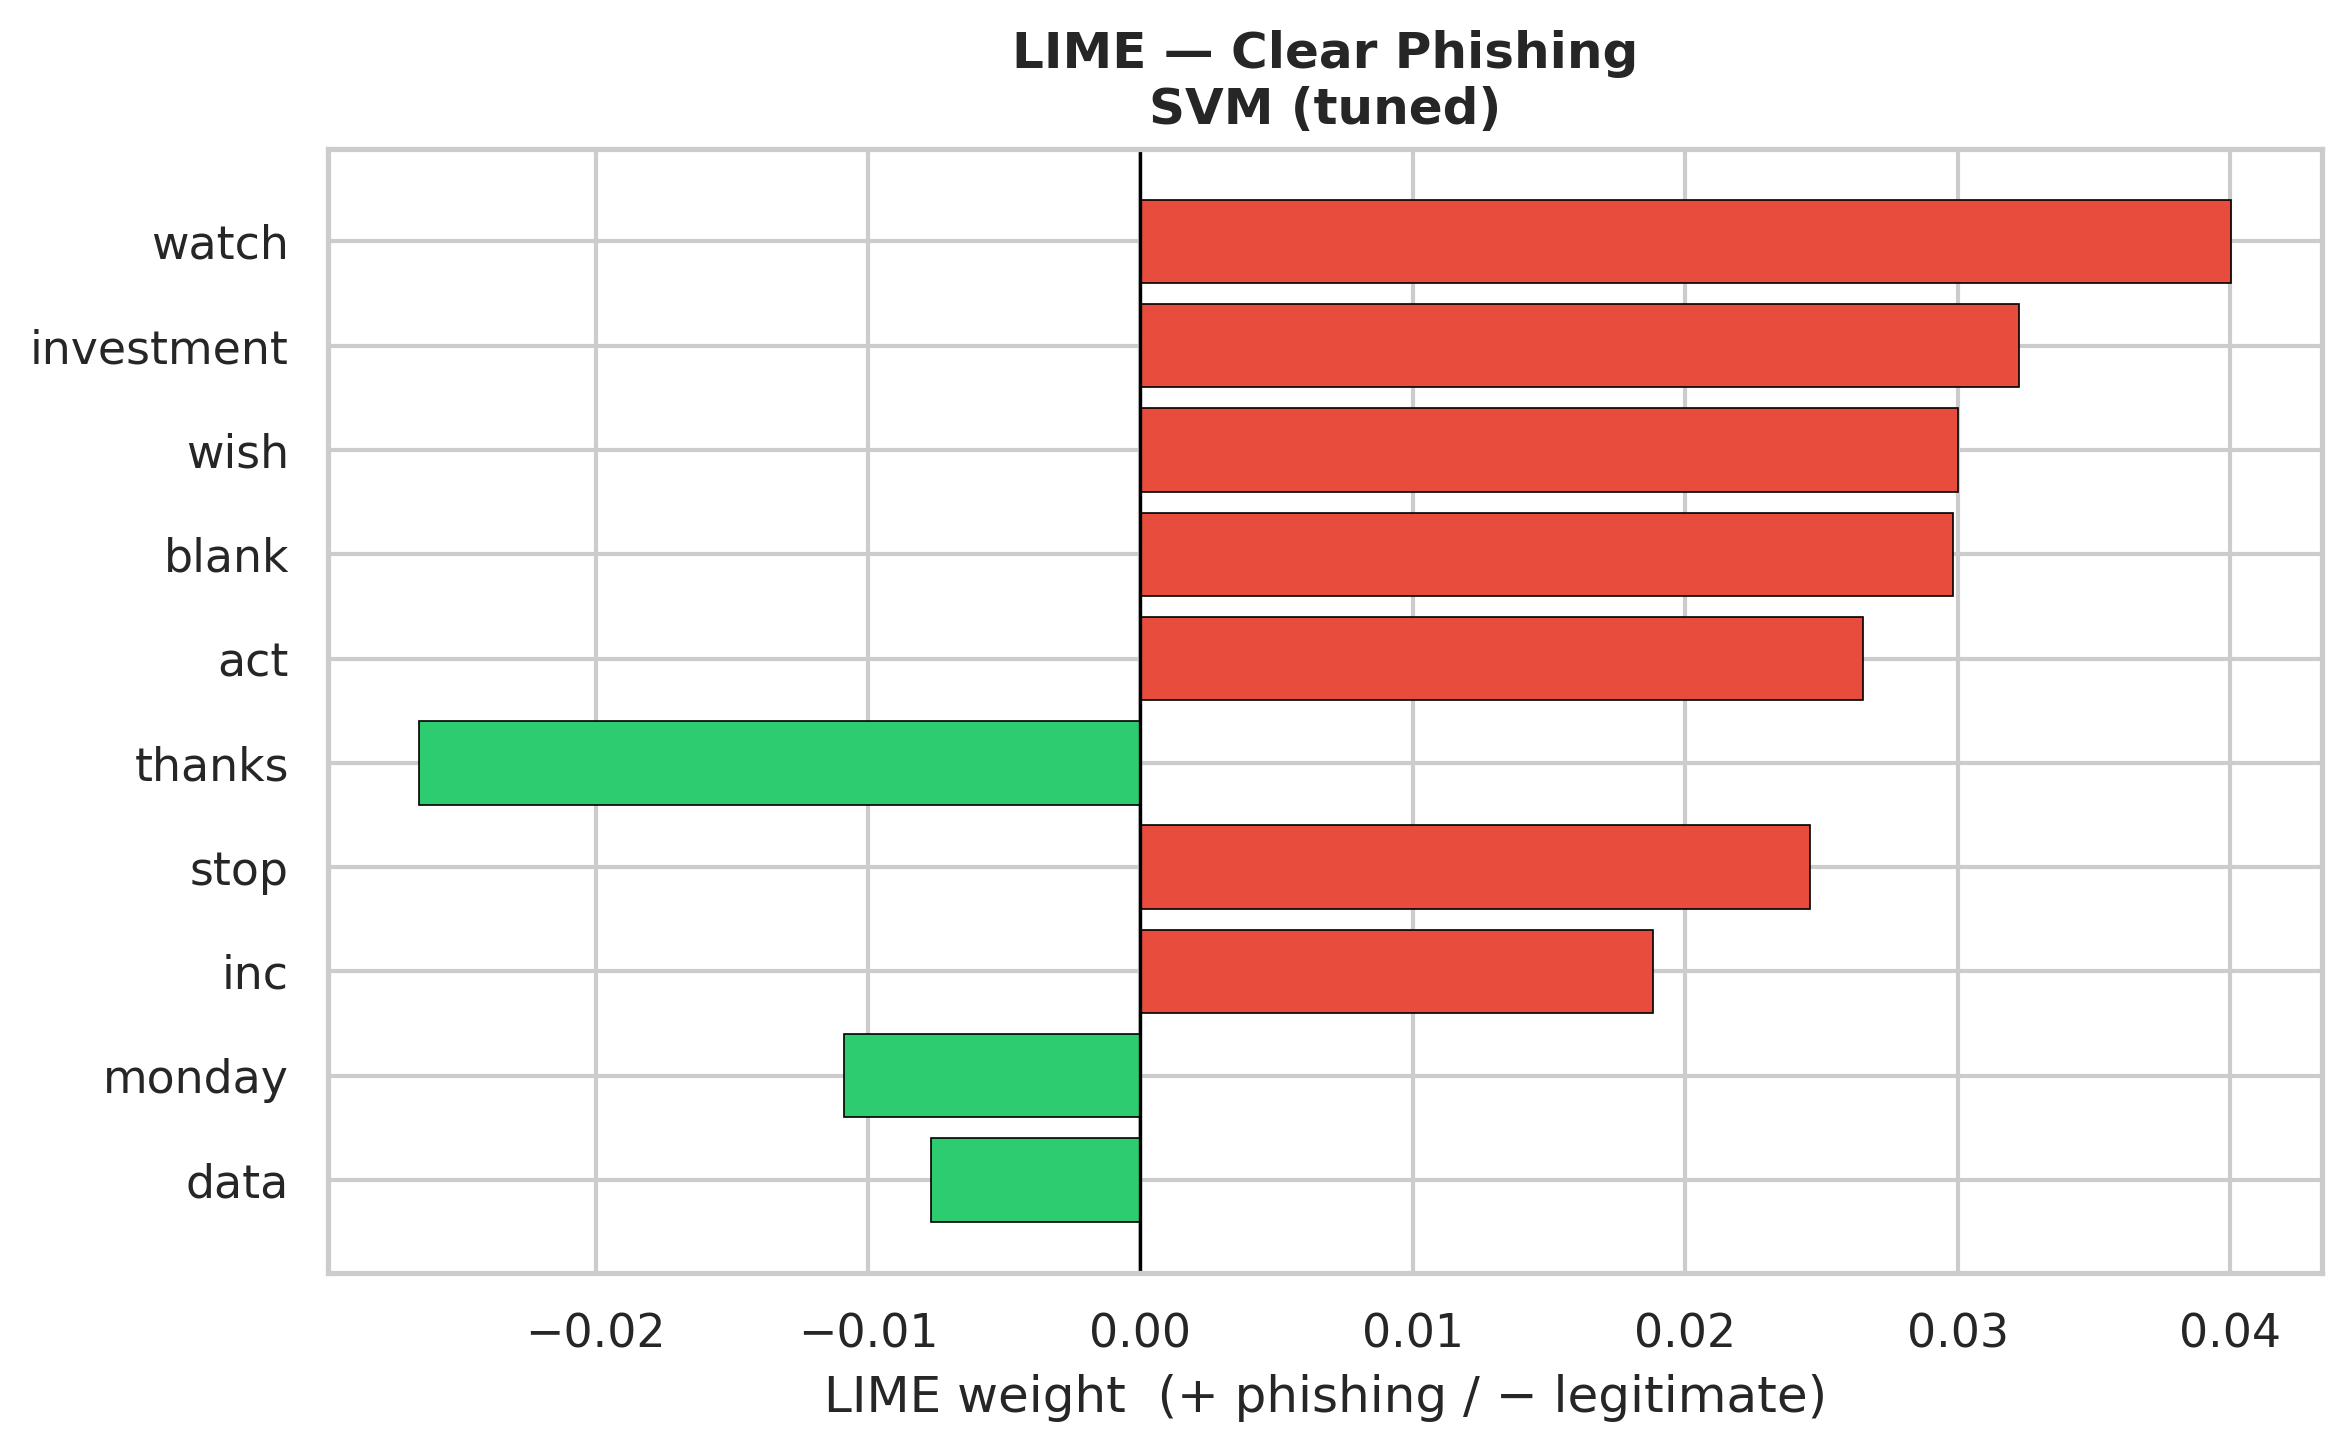

  ✓ clear_phishing  → rq9_lime_clear_phishing.png / .html


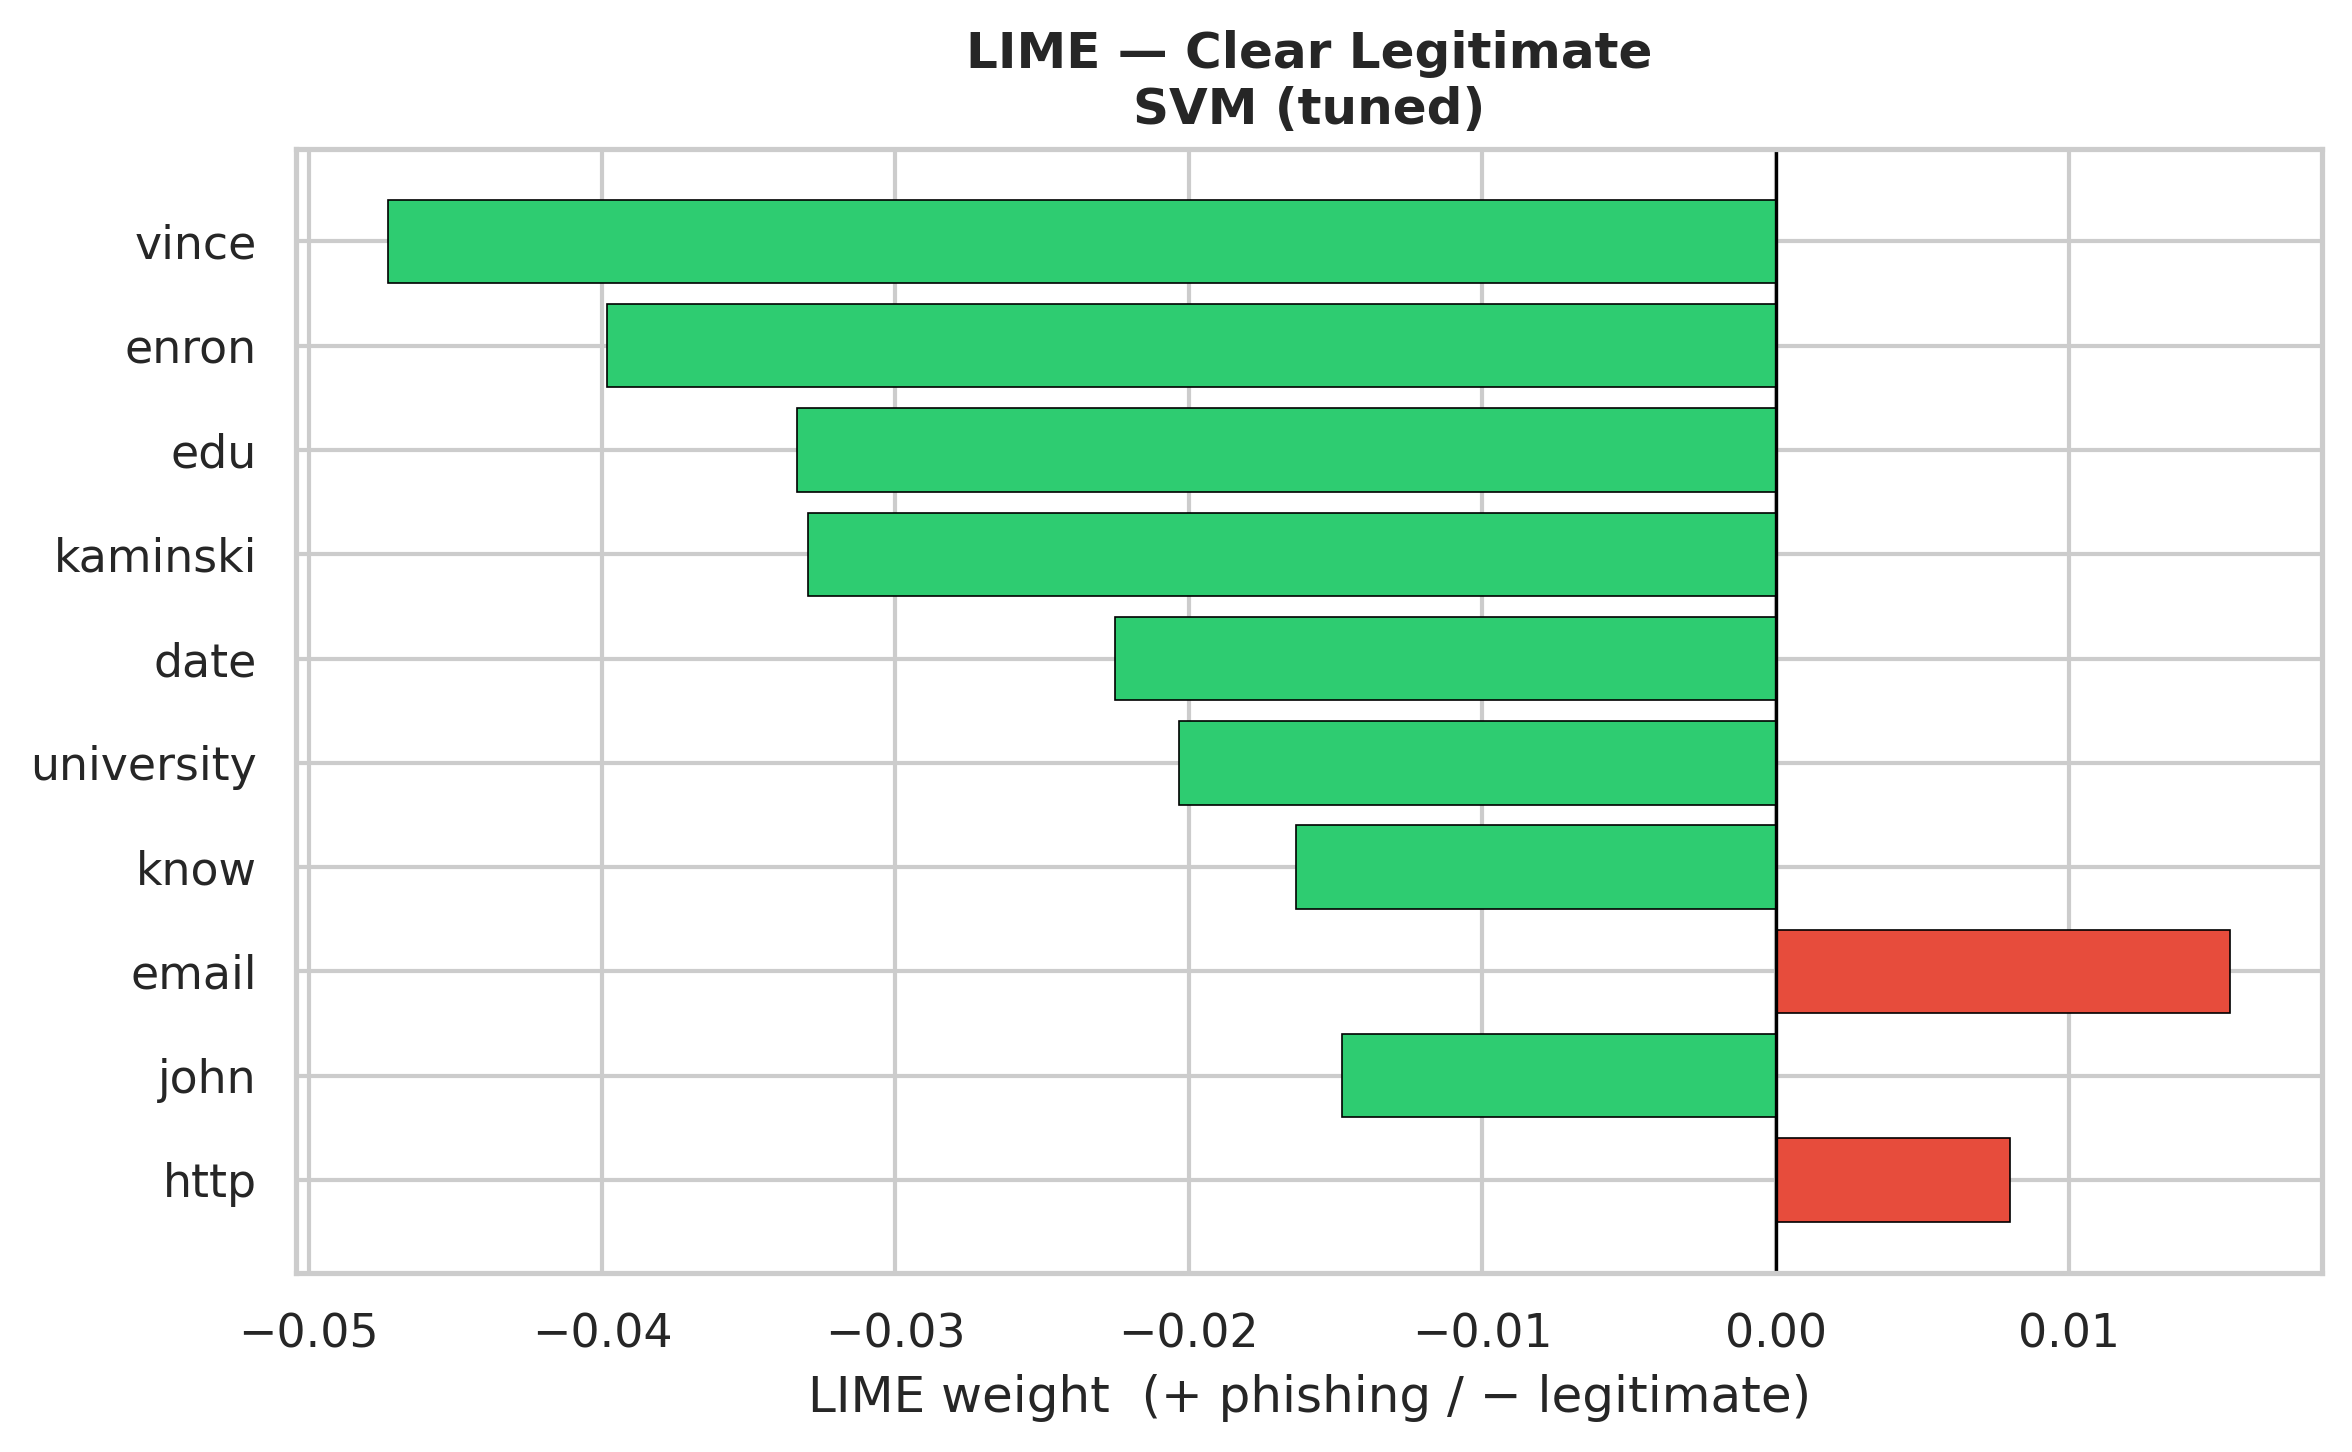

  ✓ clear_legitimate  → rq9_lime_clear_legitimate.png / .html


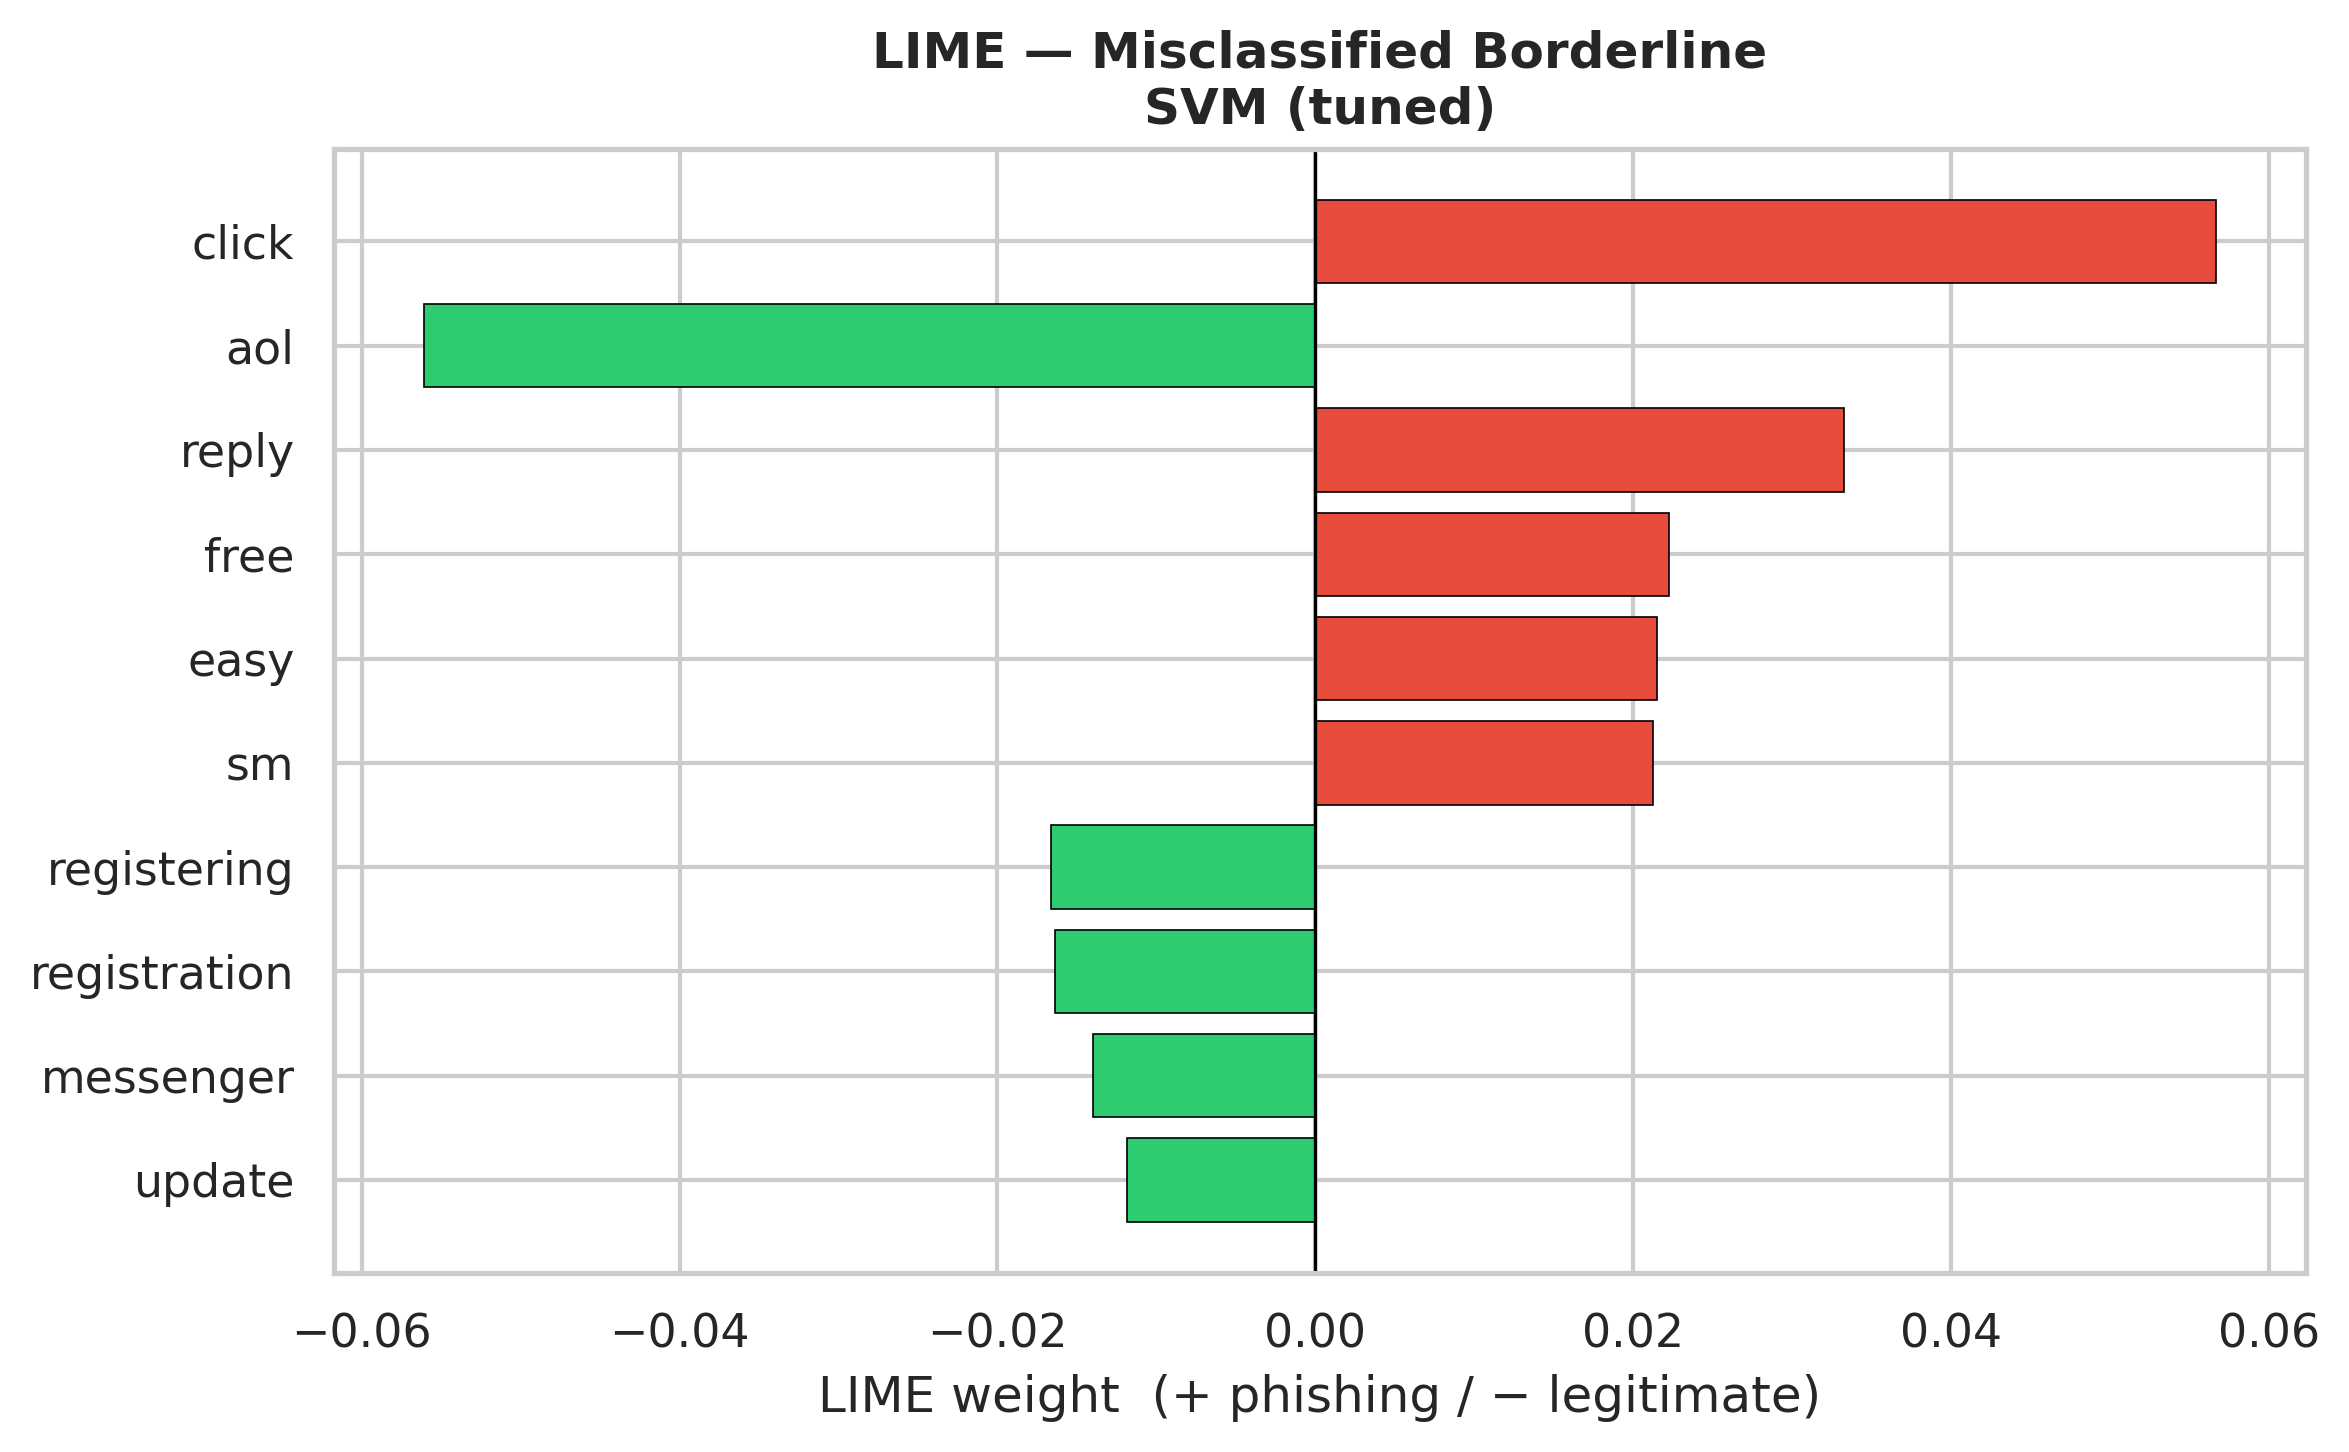

  ✓ misclassified_borderline  → rq9_lime_misclassified_borderline.png / .html
✓ Saved lime_explanations.csv


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✓ DistilBERT loaded (eager attention) from /content/drive/MyDrive/NLP FINAL/rq6_transformer/models/distilbert_phishguard

Running SHAP on DistilBERT (3 truncated examples)...
  SHAP → clear_phishing ...


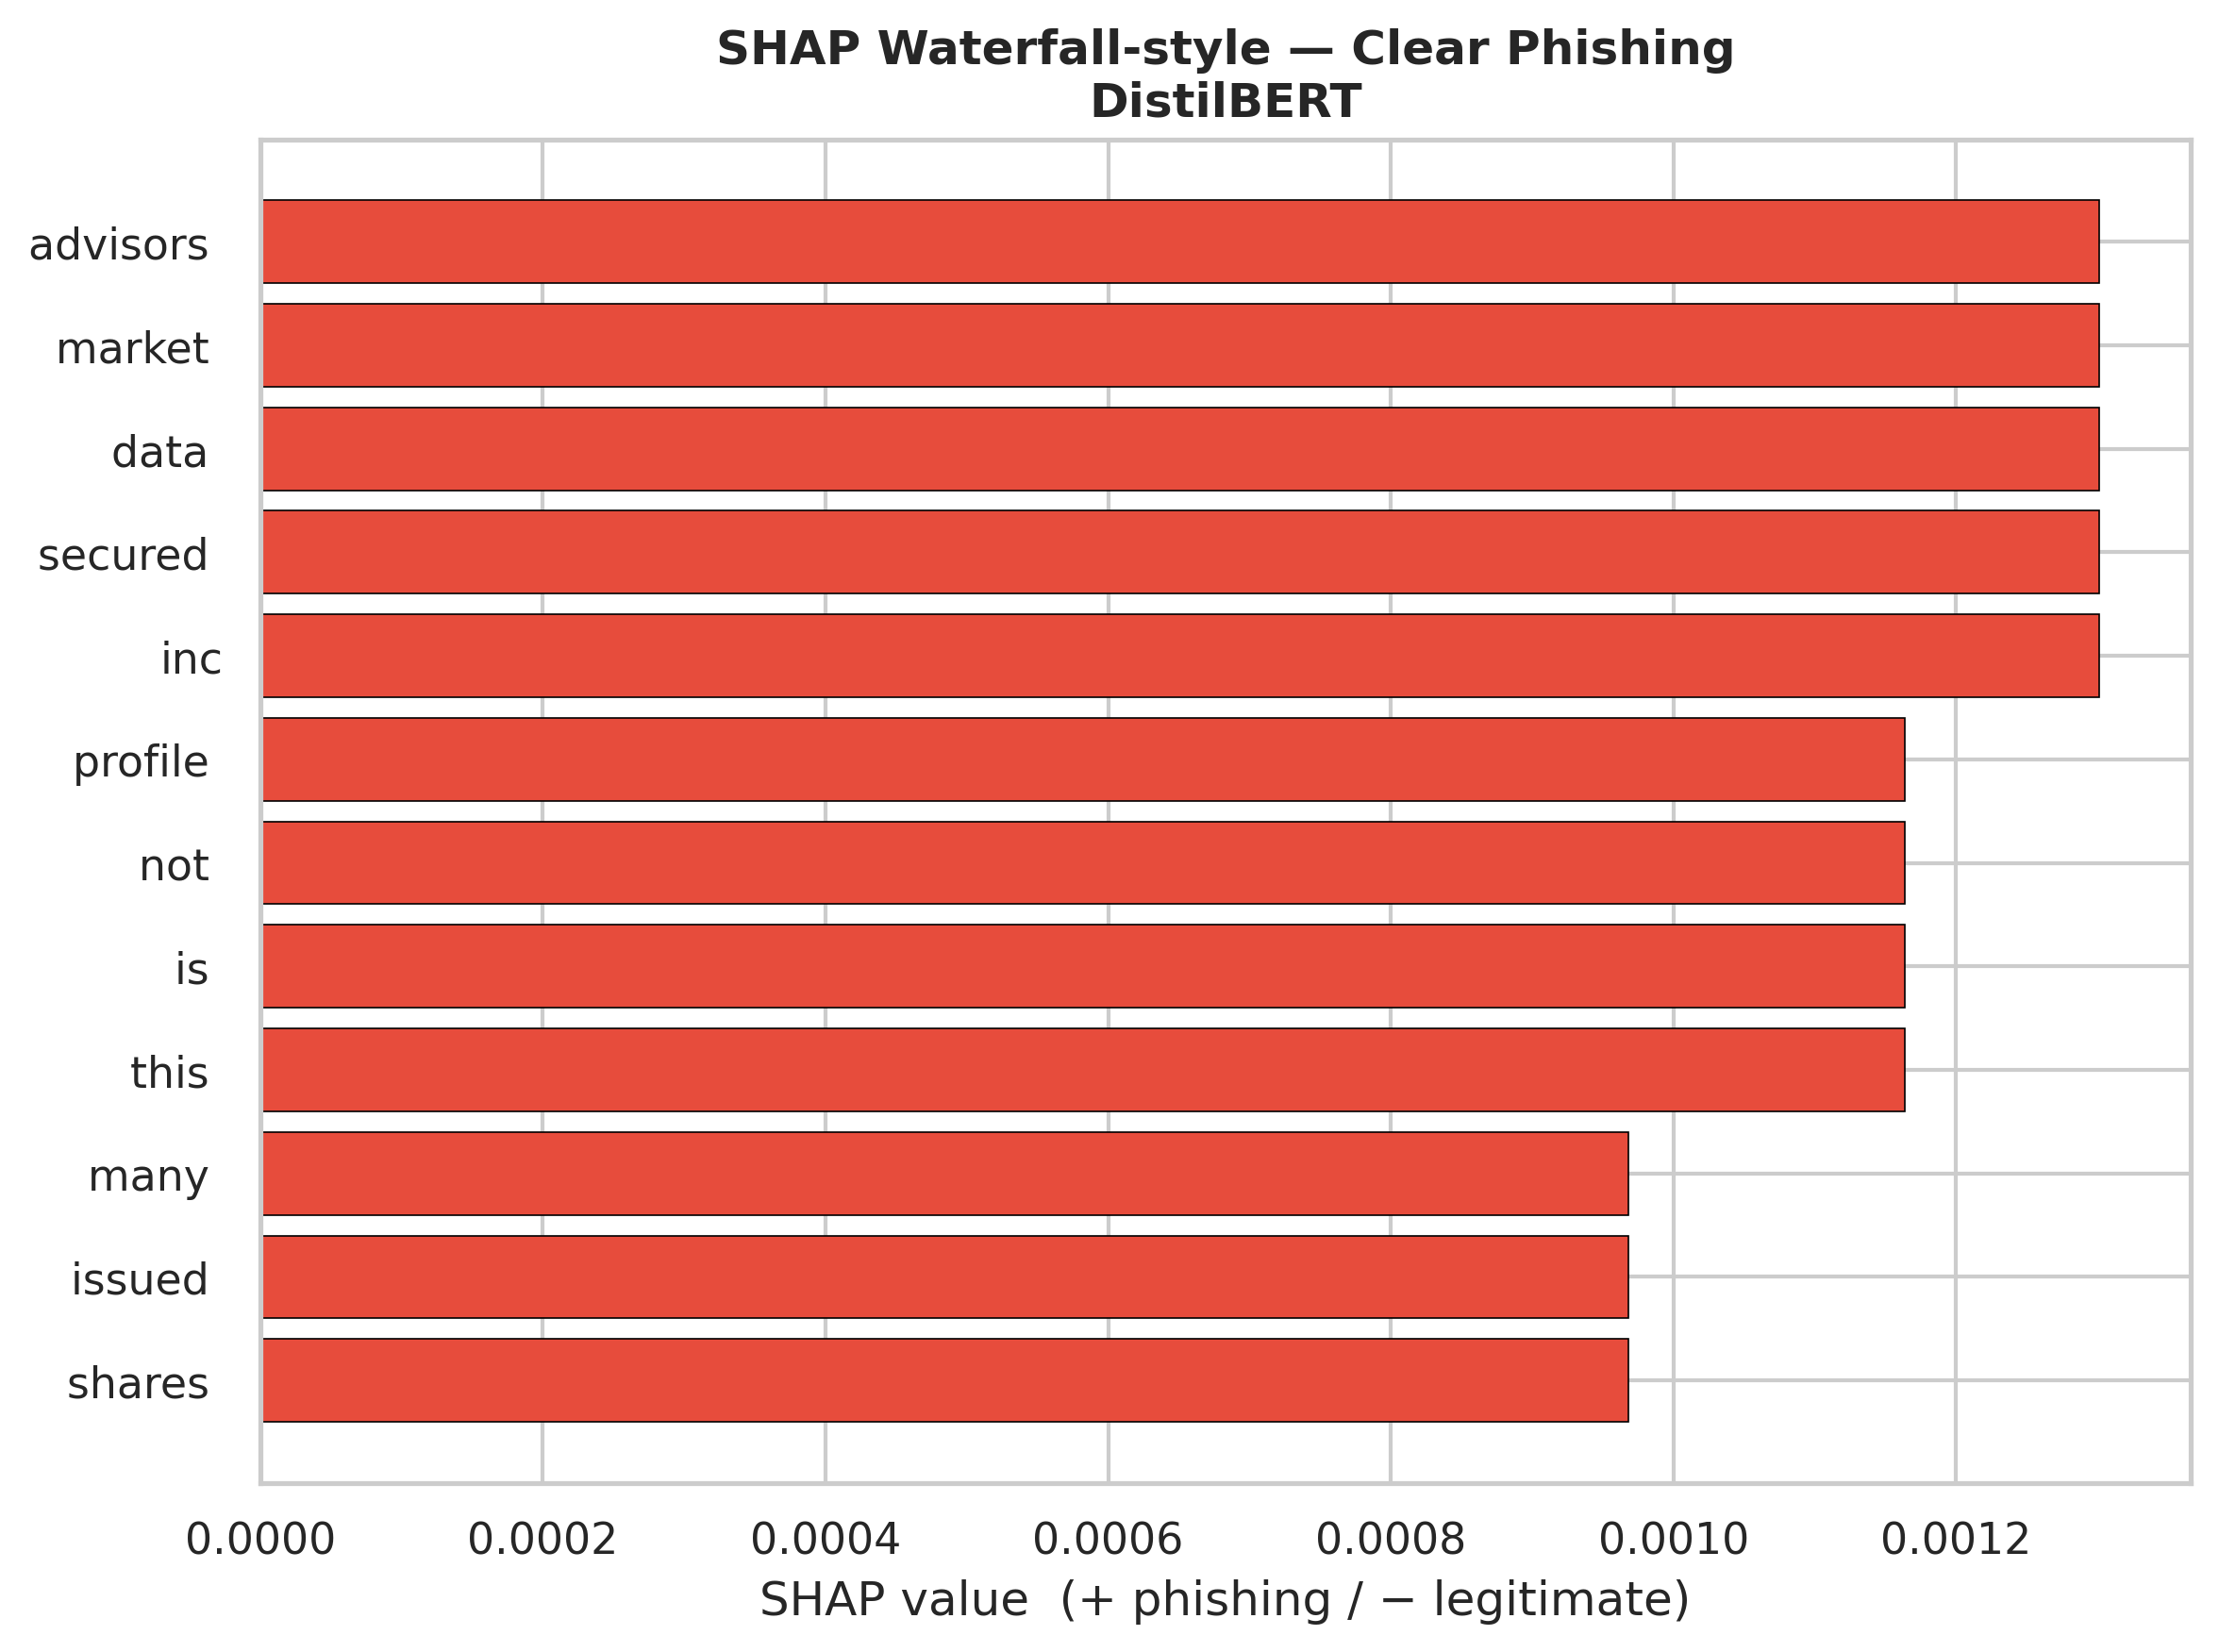

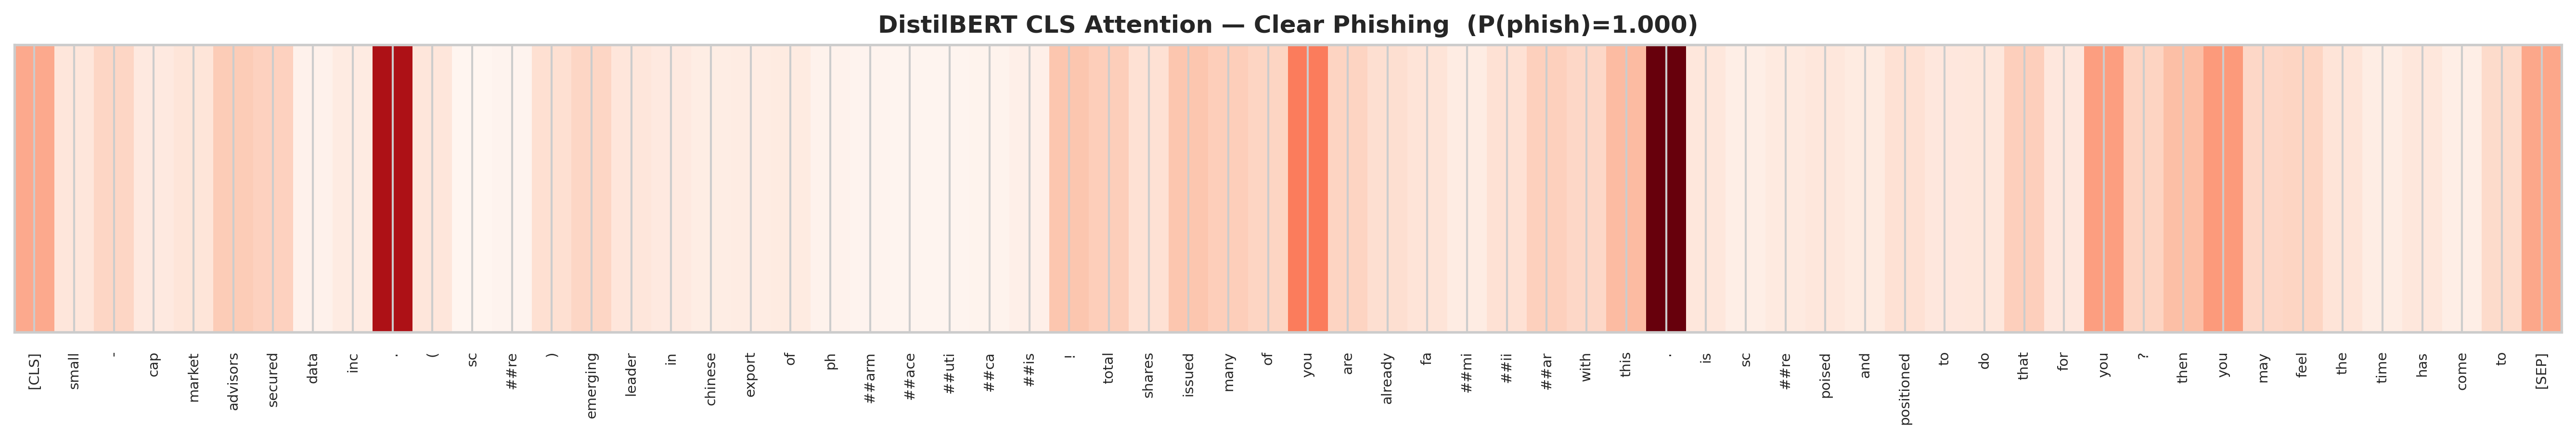

  ✓ clear_phishing
  SHAP → clear_legitimate ...


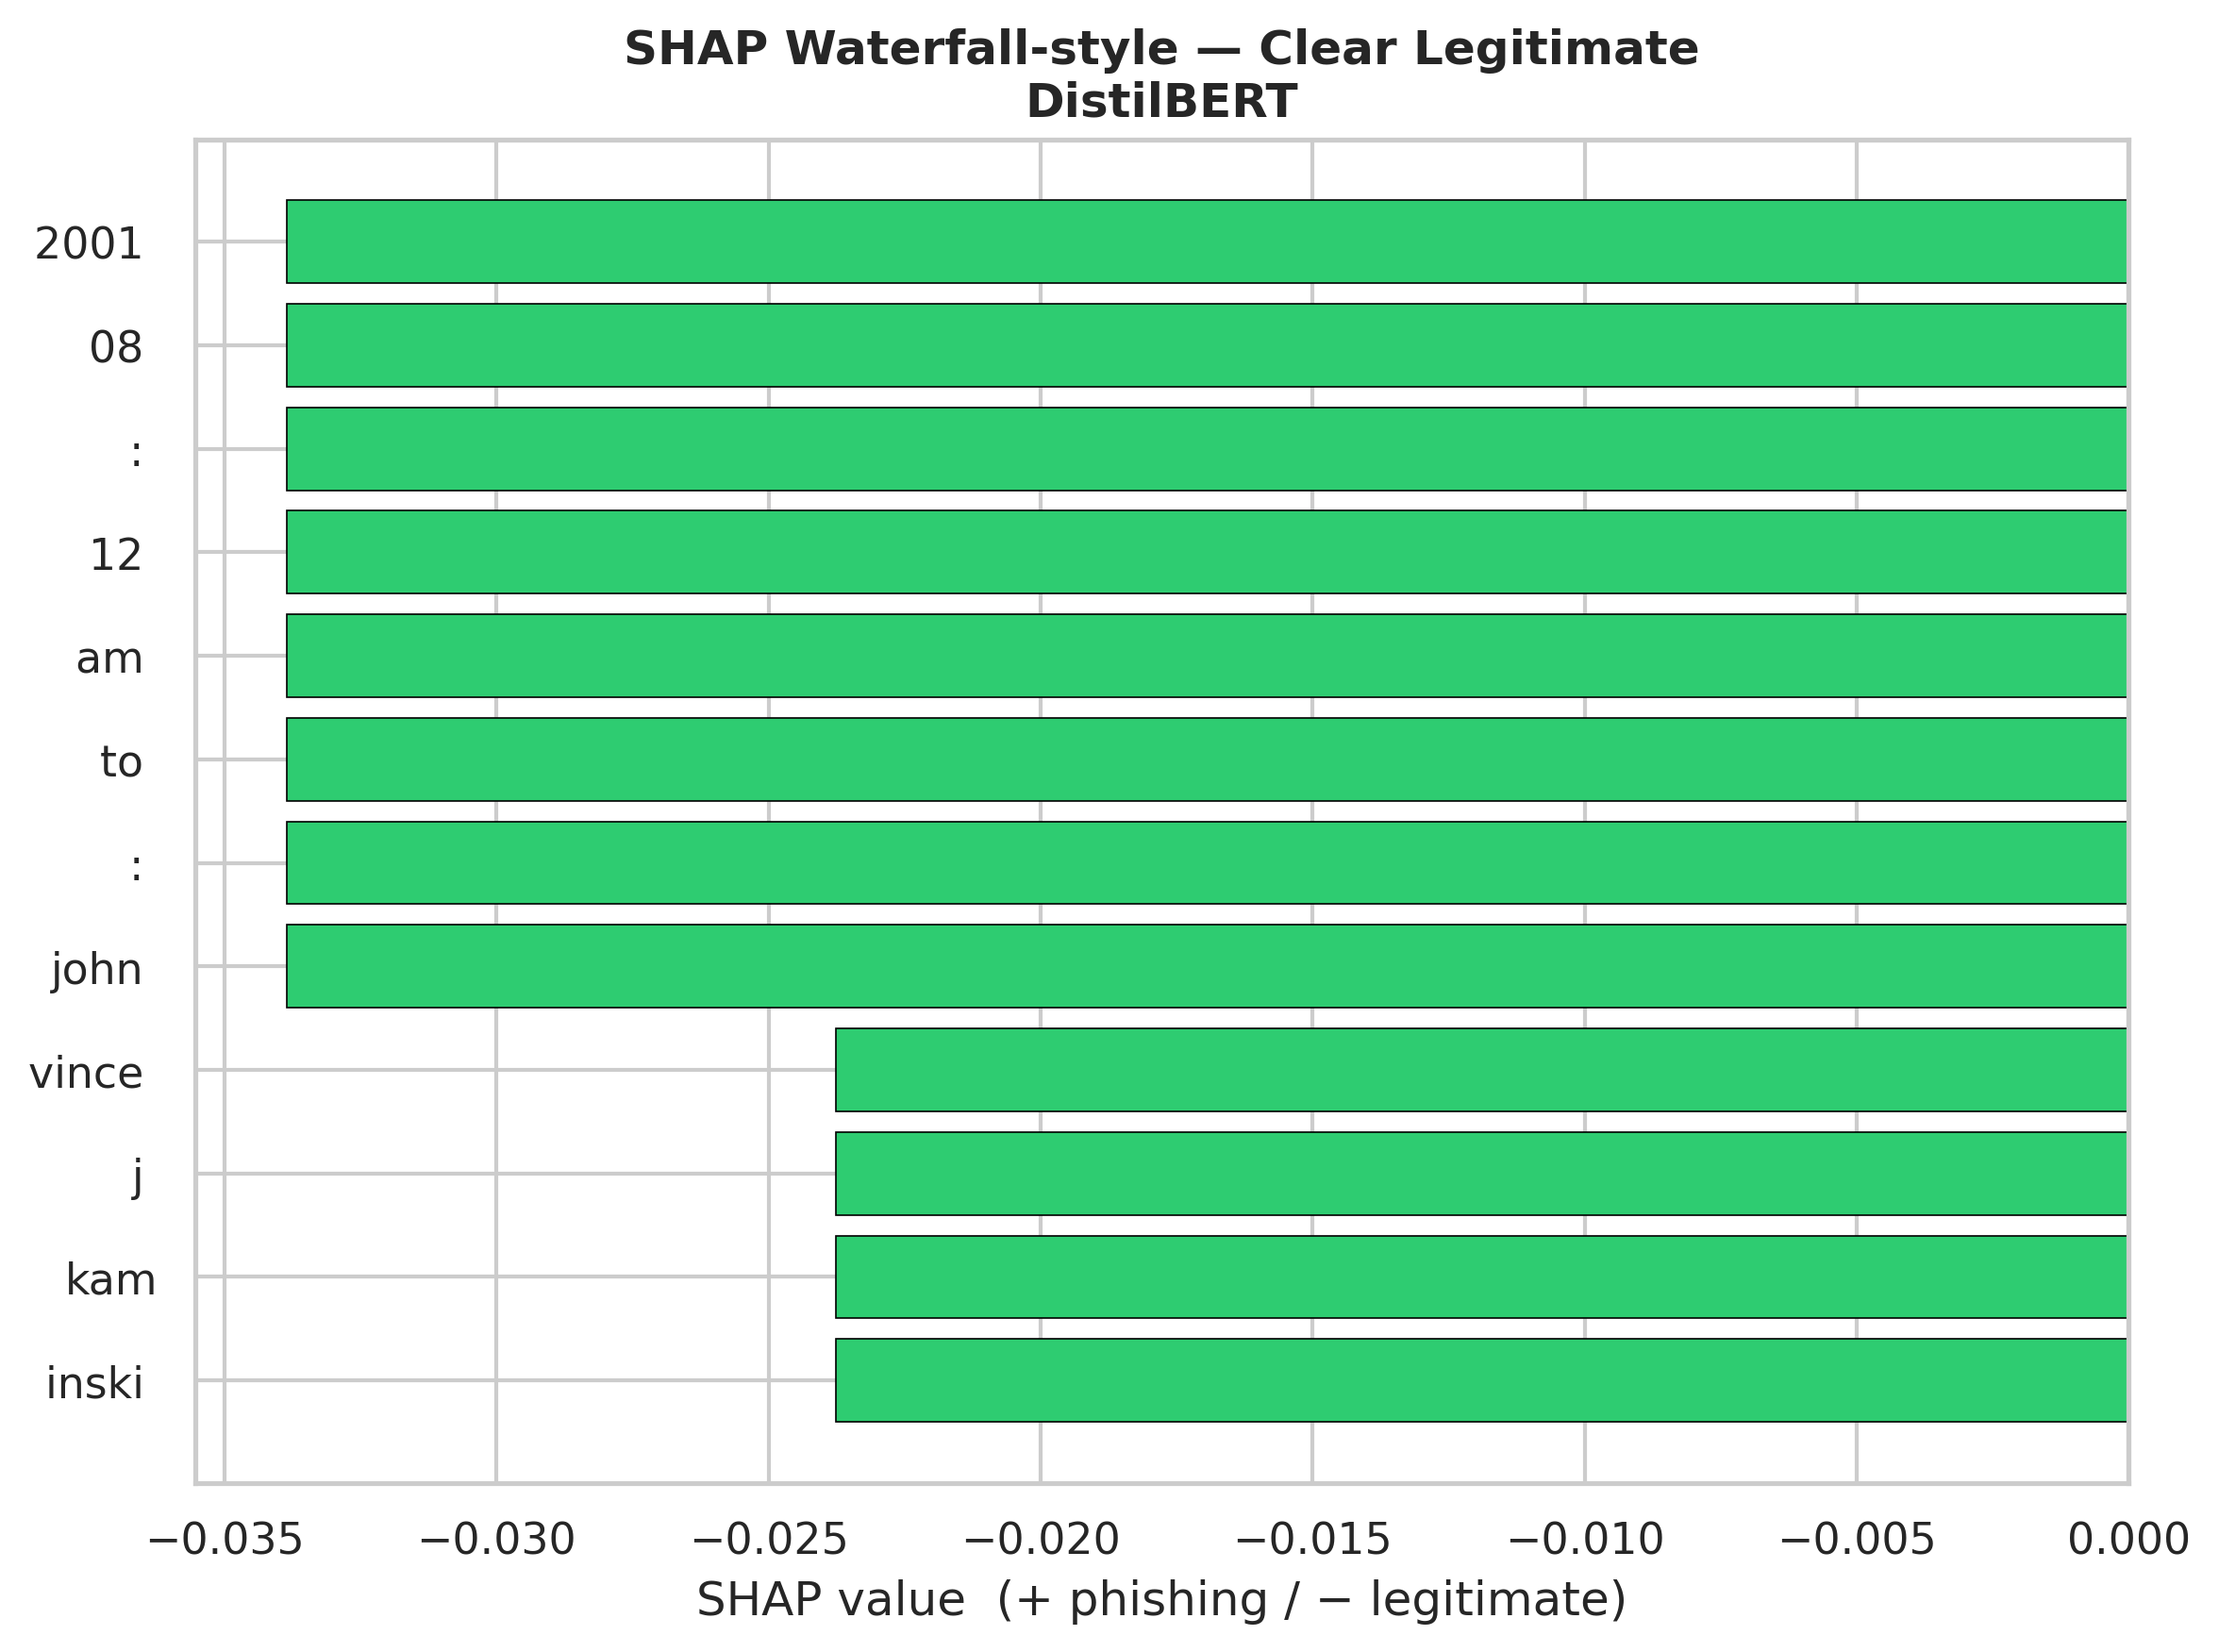

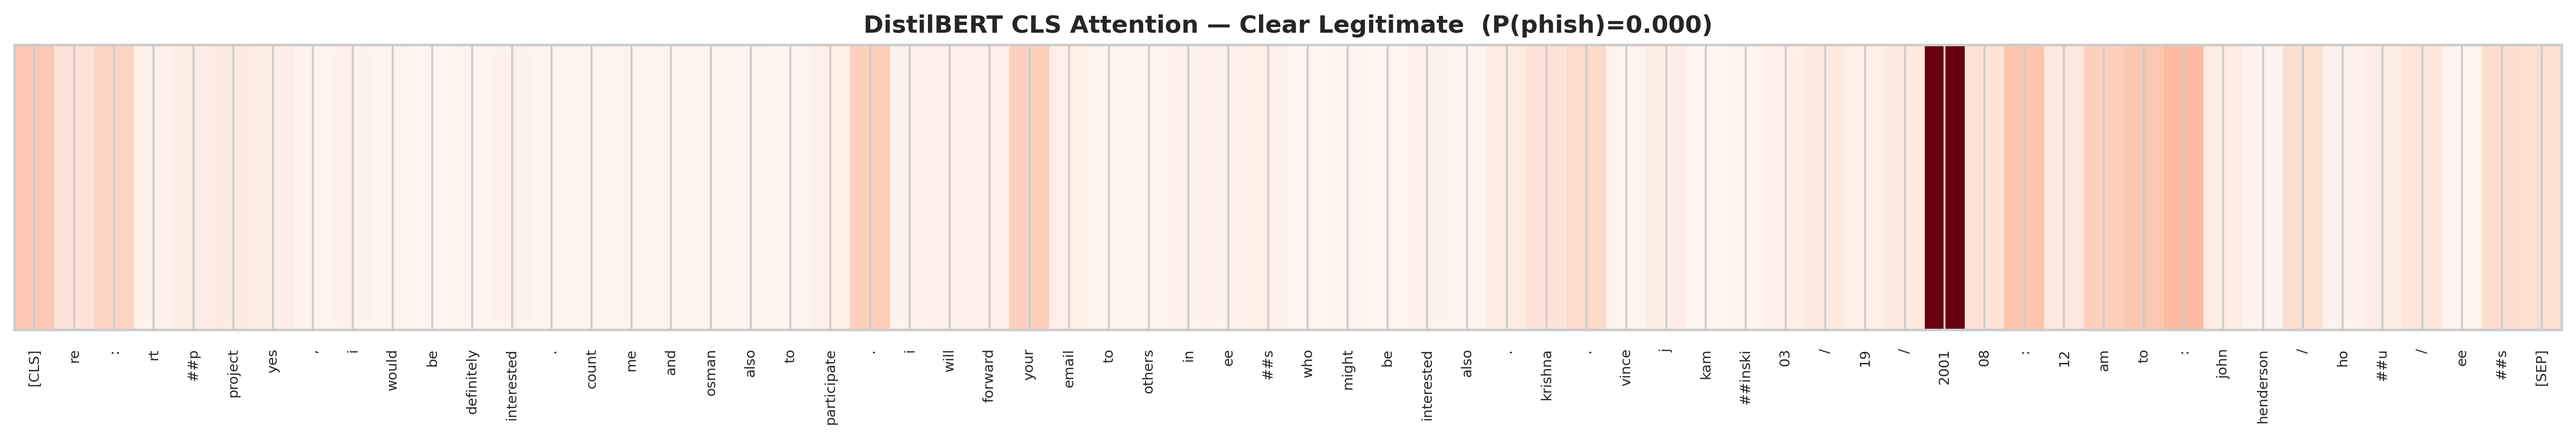

  ✓ clear_legitimate
  SHAP → misclassified_borderline ...


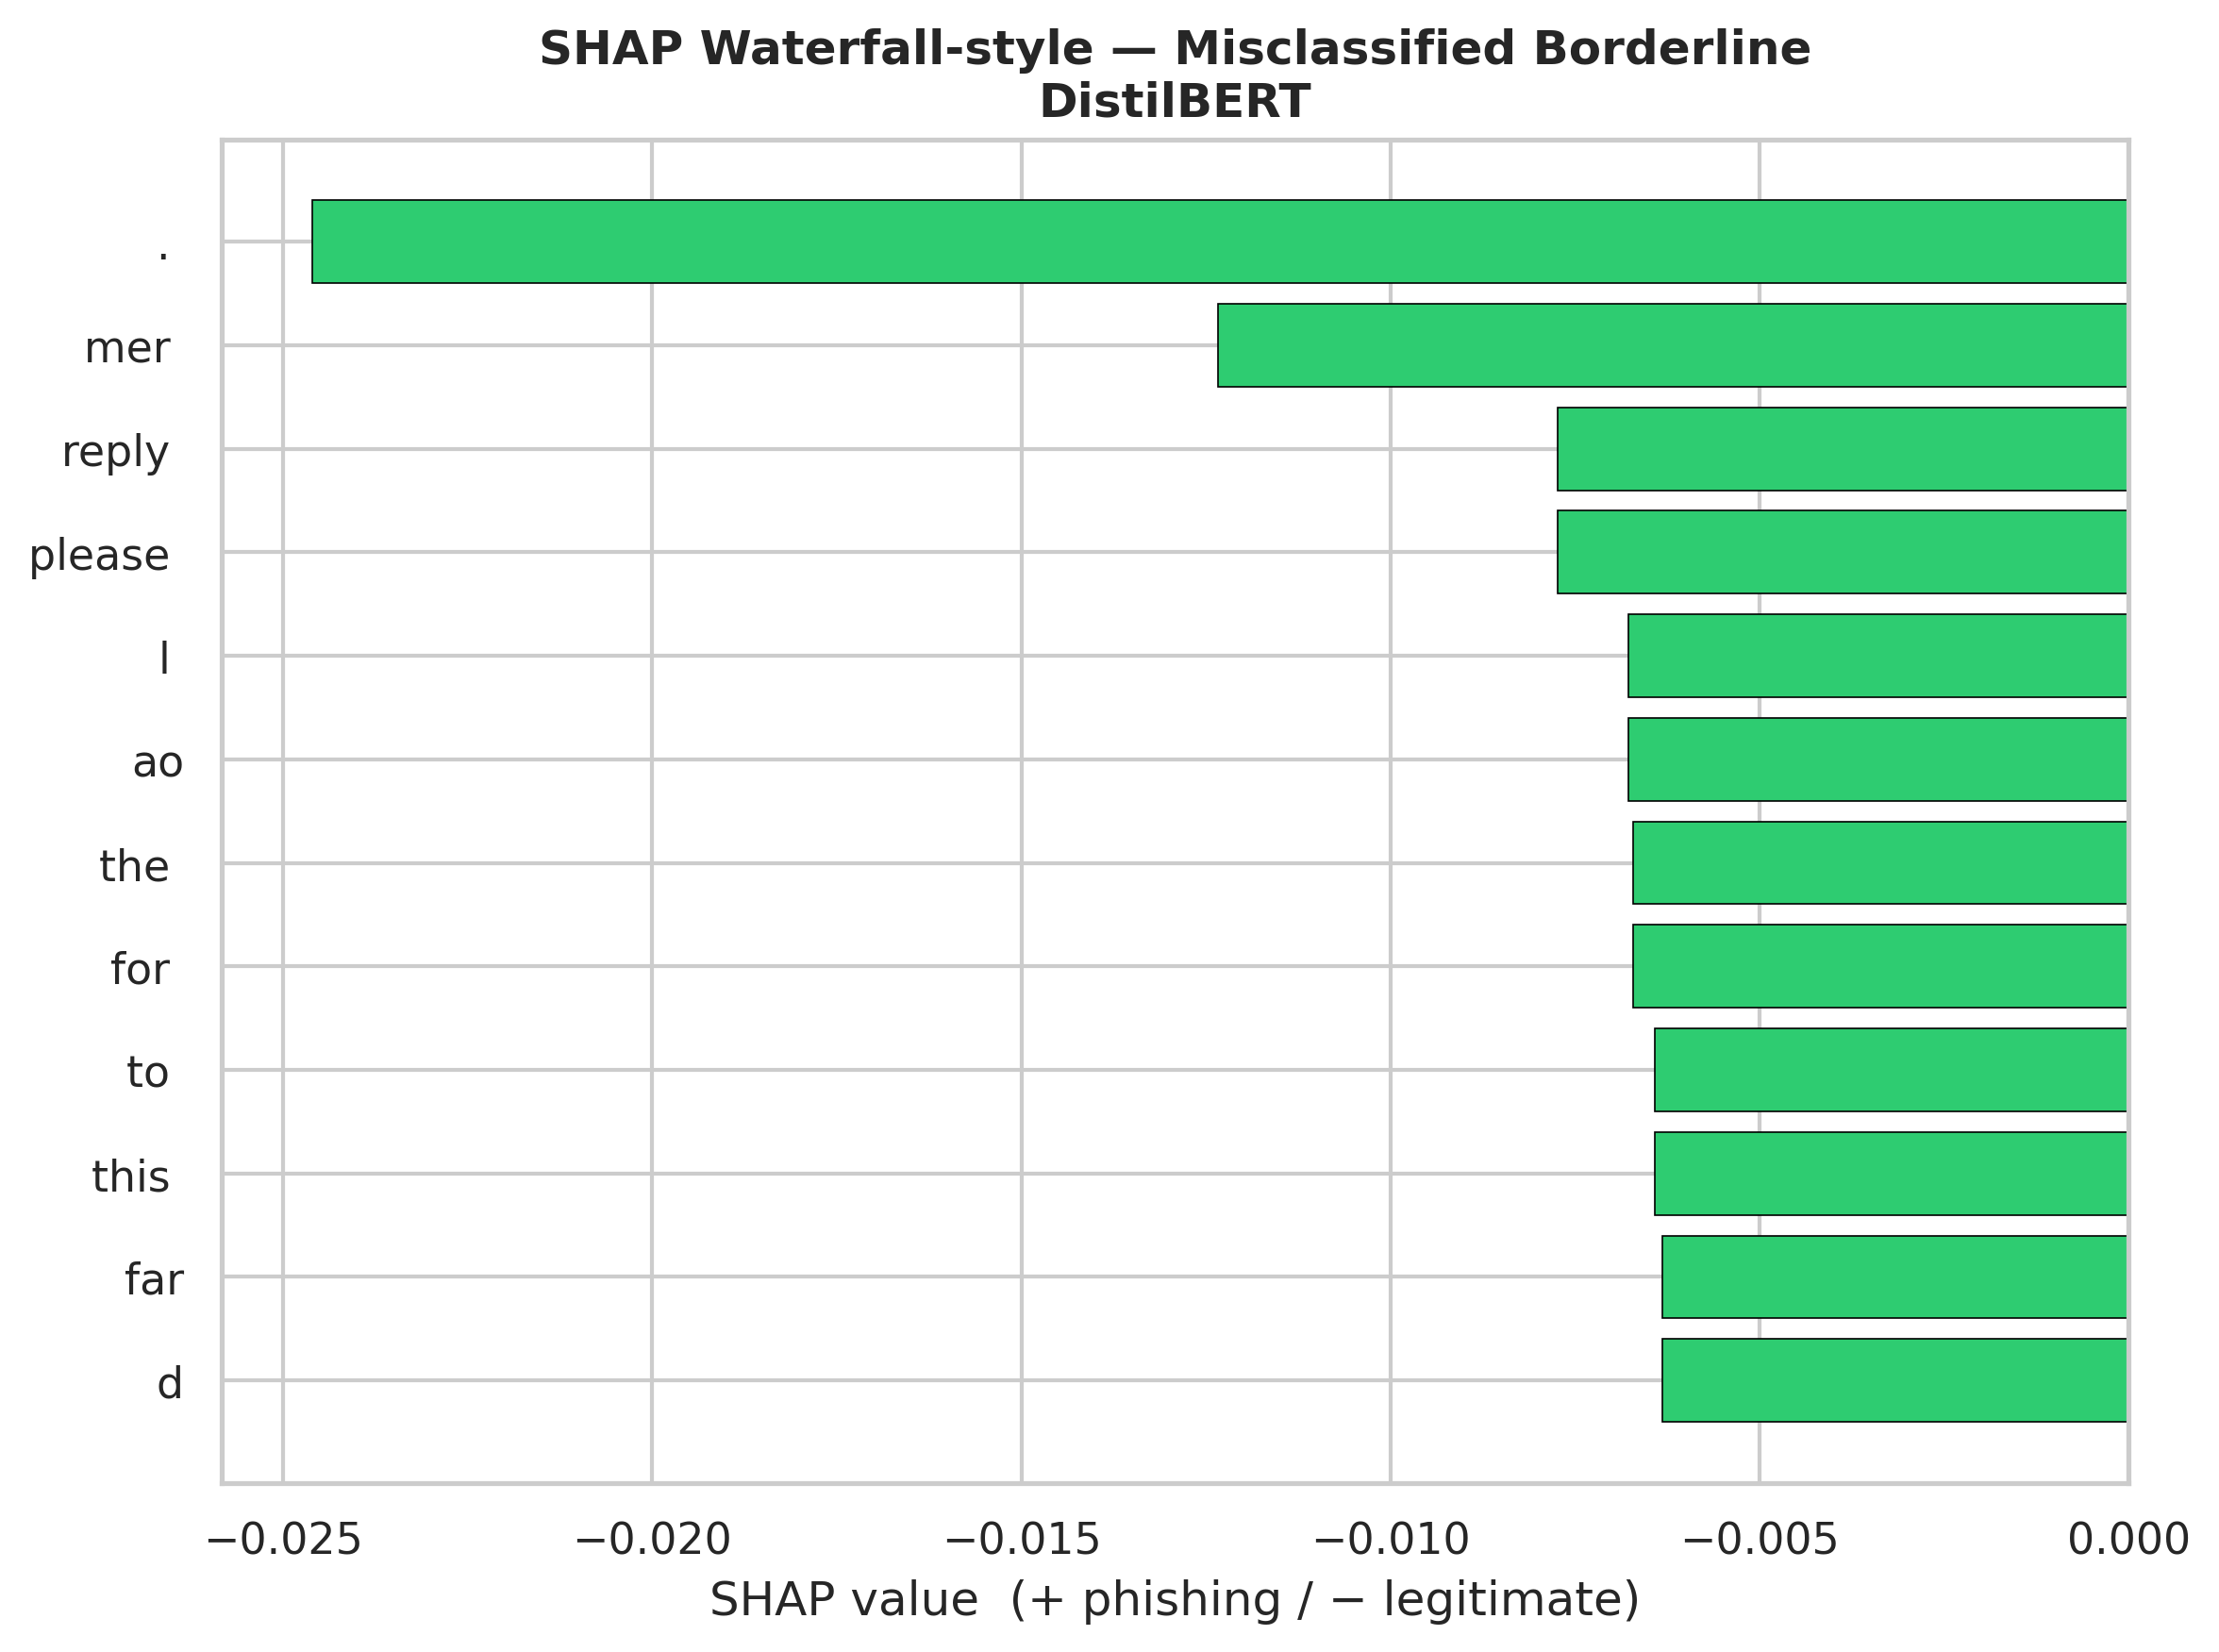

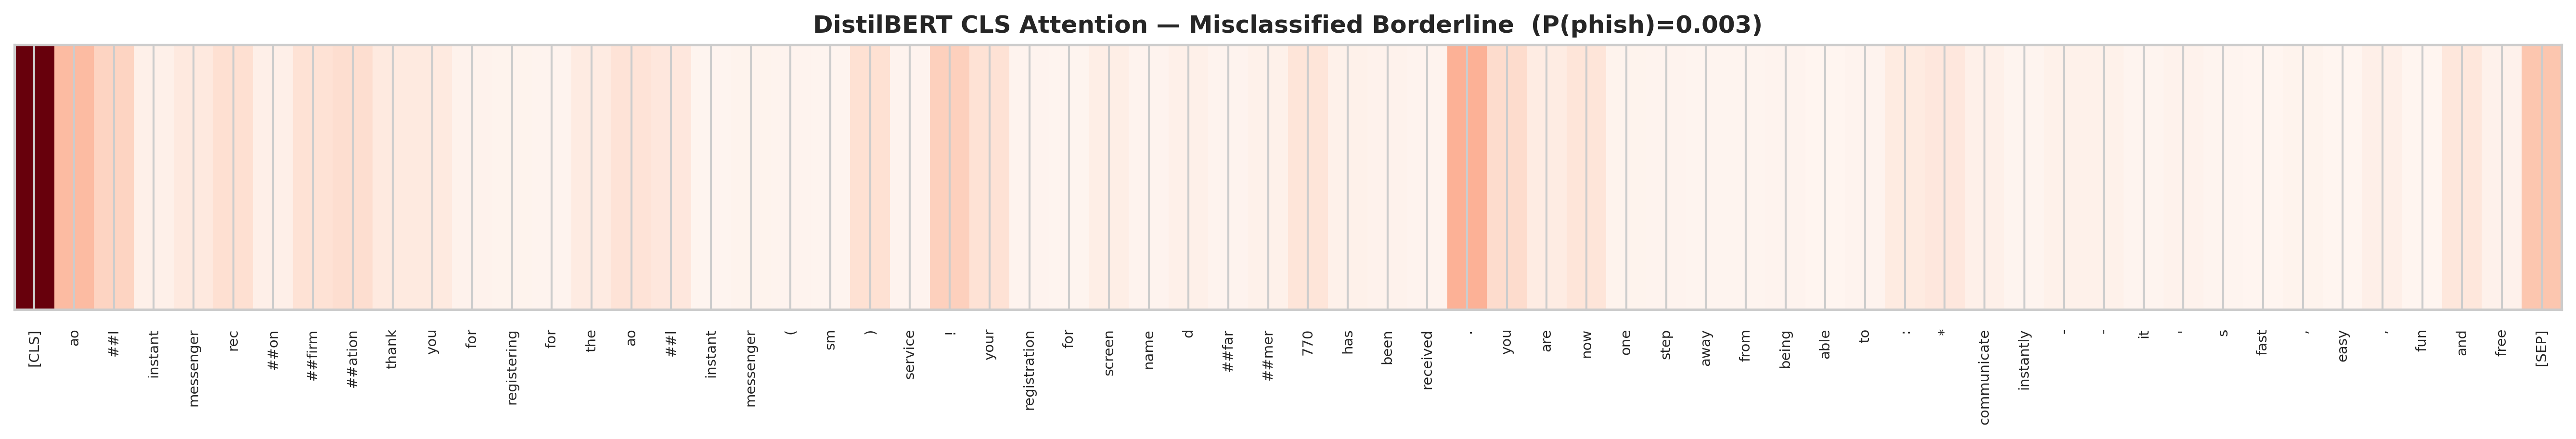

  ✓ misclassified_borderline
✓ Saved shap_examples.csv

RQ9 — EXPLAINABILITY COMPLETE ✓

LIME model : SVM (tuned)
LIME caps  : num_features=10, num_samples=250

Results → /content/drive/MyDrive/NLP FINAL/rq9_explainability/results/
  lime_explanations.csv
  shap_examples.csv
  error_analysis.csv
  experiment_config.csv

Diagrams → /content/drive/MyDrive/NLP FINAL/rq9_explainability/diagrams/
  rq9_lime_*.png / .html
  rq9_shap_*.png
  rq9_attention_*.png

── LIME summary ──


/tmp/ipykernel_21278/3234253781.py:459: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),


,case_type,true_name,pred_name,phishing_prob,top_phishing_words
0,clear_phishing,Phishing,Phishing,0.797022,watch(+0.040) | investment(+0.032) | wish(+0.0...
1,clear_legitimate,Legitimate,Legitimate,0.068117,email(+0.015) | http(+0.008)
2,misclassified_borderline,Legitimate,Phishing,0.687174,click(+0.057) | reply(+0.033) | free(+0.022) |...



── SHAP summary ──


,case_type,true_name,bert_pred,bert_prob,top_tokens
0,clear_phishing,Phishing,1,0.999625,advisors (+0.0013) | market (+0.0013) | data (...
1,clear_legitimate,Legitimate,0,0.000194,2001 (-0.0339) | 08 (-0.0339) | : (-0.0339) | ...
2,misclassified_borderline,Legitimate,1,0.520835,. (-0.0246) | mer (-0.0123) | reply (-0.0077) ...



Next step → RQ10 (Streamlit app + deployment_models copy)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PhishGuard AI — RQ9: Explainability (LIME + DistilBERT SHAP / attention)
# FIX: DistilBERT loaded with attn_implementation="eager" so attentions exist
# LIME: best classical model | num_features=10 | num_samples=250
# DistilBERT: 3 emails — clear phishing, clear legitimate, misclassified/borderline
# ═══════════════════════════════════════════════════════════════════════════════

# ═══ CELL 1 — Reproducibility Block ═══
import os, random, numpy as np, torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Reproducibility block applied (SEED=42) | Device: {DEVICE}")


# ═══ CELL 2 — Drive mount + folder tree ═══
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR     = "/content/drive/MyDrive/NLP FINAL"
DATASET_DIR  = os.path.join(BASE_DIR, "dataset")
STAGE_DIR    = os.path.join(BASE_DIR, "rq9_explainability")
RQ3_MODELS   = os.path.join(BASE_DIR, "rq3_feature_engineering", "models")
RQ4_MODELS   = os.path.join(BASE_DIR, "rq4_classical_ml", "models")
RQ4_RESULTS  = os.path.join(BASE_DIR, "rq4_classical_ml", "results")
RQ6_MODEL    = os.path.join(BASE_DIR, "rq6_transformer", "models", "distilbert_phishguard")
RQ6_RESULTS  = os.path.join(BASE_DIR, "rq6_transformer", "results")
RQ7_MODELS   = os.path.join(BASE_DIR, "rq7_hyperparameter_tuning", "models")
RQ7_RESULTS  = os.path.join(BASE_DIR, "rq7_hyperparameter_tuning", "results")

MODELS_DIR   = os.path.join(STAGE_DIR, "models")
LOGS_DIR     = os.path.join(STAGE_DIR, "logs")
RESULTS_DIR  = os.path.join(STAGE_DIR, "results")
DIAGRAMS_DIR = os.path.join(STAGE_DIR, "diagrams")

for folder in [MODELS_DIR, LOGS_DIR, RESULTS_DIR, DIAGRAMS_DIR]:
    os.makedirs(folder, exist_ok=True)

TEST_PATH  = os.path.join(DATASET_DIR, "test.csv")
TFIDF_PATH = os.path.join(RQ3_MODELS, "tfidf_vectorizer.pkl")

for p in [TEST_PATH, TFIDF_PATH, os.path.join(RQ4_RESULTS, "overall_metrics.csv")]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing: {p}")

print(f"✓ STAGE_DIR : {STAGE_DIR}")


# ═══ CELL 3 — Install + imports ═══
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "lime", "shap", "transformers", "scikit-learn",
                       "joblib", "matplotlib", "seaborn"])

import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from datetime import datetime
from scipy.special import expit
from lime.lime_text import LimeTextExplainer
from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DPI = 300
LIME_NUM_FEATURES = 10
LIME_NUM_SAMPLES  = 250
SHAP_MAX_LEN      = 128
ATTN_MAX_LEN      = 64
LABEL_NAMES       = ["Legitimate", "Phishing"]

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = DPI
plt.rcParams["savefig.dpi"] = DPI


# ═══ CELL 4 — Pick best classical model (RQ4 + RQ7) ═══
candidates = []

rq4_m = pd.read_csv(os.path.join(RQ4_RESULTS, "overall_metrics.csv"))
for _, row in rq4_m.iterrows():
    candidates.append({
        "model_key": row["model_key"],
        "model_name": row["model_name"],
        "macro_f1": float(row["macro_f1"]),
        "source": "RQ4",
        "path": os.path.join(RQ4_MODELS, f"{row['model_key']}.pkl"),
    })

rq7_metrics_path = os.path.join(RQ7_RESULTS, "tuned_overall_metrics.csv")
if os.path.exists(rq7_metrics_path):
    rq7_m = pd.read_csv(rq7_metrics_path)
    for _, row in rq7_m.iterrows():
        candidates.append({
            "model_key": row["model_key"],
            "model_name": f"{row['model_name']} (tuned)",
            "macro_f1": float(row["macro_f1"]),
            "source": "RQ7",
            "path": os.path.join(RQ7_MODELS, f"{row['model_key']}.pkl"),
        })

cand_df = pd.DataFrame(candidates)
cand_df = cand_df[cand_df["path"].map(os.path.exists)].copy()
if cand_df.empty:
    raise FileNotFoundError("No classical model pickle found. Run RQ4 first.")

# Highest Macro-F1; tie-break prefers RQ7 tuned SVM (deployment model)
cand_df["tie_rank"] = cand_df["model_key"].map(lambda k: 0 if k == "svm_tuned" else 1)
best = cand_df.sort_values(["macro_f1", "tie_rank"], ascending=[False, True]).iloc[0]

print("Classical candidates:")
display(cand_df[["model_key", "model_name", "macro_f1", "source"]])
print(f"\n✓ LIME model : {best['model_name']}  ({best['source']})")
print(f"  Path        : {best['path']}")


# ═══ CELL 5 — Load artifacts (never refit) ═══
tfidf = joblib.load(TFIDF_PATH)
classical_model = joblib.load(best["path"])
test_df = pd.read_csv(TEST_PATH)

rq4_preds = pd.read_csv(os.path.join(RQ4_RESULTS, "test_predictions.csv"))
rq6_preds_path = os.path.join(RQ6_RESULTS, "test_predictions.csv")
if not os.path.exists(rq6_preds_path):
    raise FileNotFoundError("RQ6 test_predictions.csv missing — run RQ6 first.")
rq6_preds = pd.read_csv(rq6_preds_path)

assert len(test_df) == len(rq4_preds) == len(rq6_preds), "Split length mismatch — do not re-split."

y_true = test_df["label"].values


def classical_proba_matrix(texts):
    """LIME-compatible (n, 2) probabilities. Same fn the app will reuse."""
    X = tfidf.transform([str(t) for t in texts])
    if hasattr(classical_model, "predict_proba"):
        return classical_model.predict_proba(X)
    scores = expit(np.asarray(classical_model.decision_function(X)).reshape(-1))
    return np.column_stack([1.0 - scores, scores])


lime_probs = classical_proba_matrix(test_df["text_cleaned_classical"].astype(str).tolist())[:, 1]
lime_preds = (lime_probs >= 0.5).astype(int)
bert_probs = rq6_preds["distilbert_phishing_prob"].values
bert_preds = rq6_preds["distilbert_y_pred"].values

work = test_df.copy()
work["y_true"] = y_true
work["lime_prob"] = lime_probs
work["lime_pred"] = lime_preds
work["bert_prob"] = bert_probs
work["bert_pred"] = bert_preds
work["lime_correct"] = work["y_true"] == work["lime_pred"]
work["bert_correct"] = work["y_true"] == work["bert_pred"]
work["borderline_score"] = (work["bert_prob"] - 0.5).abs()

print(f"Test emails loaded: {len(work):,}")


# ═══ CELL 6 — Select 3 report examples ═══
clear_phish = work[(work["y_true"] == 1) & work["lime_correct"] & work["bert_correct"]]
clear_legit = work[(work["y_true"] == 0) & work["lime_correct"] & work["bert_correct"]]
errors = work[~work["bert_correct"]].copy()
if errors.empty:
    errors = work.copy()

examples = {
    "clear_phishing": clear_phish.sort_values("bert_prob", ascending=False).iloc[0],
    "clear_legitimate": clear_legit.sort_values("bert_prob", ascending=True).iloc[0],
    "misclassified_borderline": errors.sort_values("borderline_score", ascending=True).iloc[0],
}

print("\n── Selected examples ──")
for case, row in examples.items():
    print(f"  {case:28s} | true={int(row.y_true)} lime={int(row.lime_pred)} "
          f"({row.lime_prob:.3f}) bert={int(row.bert_pred)} ({row.bert_prob:.3f})")


# ═══ CELL 7 — Error analysis CSV ═══
cm_lime = confusion_matrix(y_true, lime_preds, labels=[0, 1])
cm_bert = confusion_matrix(y_true, bert_preds, labels=[0, 1])

error_rows = work[~work["lime_correct"] | ~work["bert_correct"]].copy()
error_rows["error_type"] = np.where(
    ~error_rows["lime_correct"] & ~error_rows["bert_correct"], "both_wrong",
    np.where(~error_rows["lime_correct"], "lime_only", "bert_only"),
)
error_rows["true_name"] = error_rows["y_true"].map({0: "Legitimate", 1: "Phishing"})
error_rows["lime_name"] = error_rows["lime_pred"].map({0: "Legitimate", 1: "Phishing"})
error_rows["bert_name"] = error_rows["bert_pred"].map({0: "Legitimate", 1: "Phishing"})

error_out = error_rows[[
    "y_true", "true_name", "lime_pred", "lime_name", "lime_prob",
    "bert_pred", "bert_name", "bert_prob", "error_type",
    "text_cleaned_classical", "text_cleaned_transformer",
]].reset_index(drop=True)
error_out.insert(0, "row_id", error_out.index)
error_out.to_csv(os.path.join(RESULTS_DIR, "error_analysis.csv"), index=False)

print(f"\nLIME  CM [TN FP; FN TP] : {cm_lime.ravel().tolist()}")
print(f"BERT  CM [TN FP; FN TP] : {cm_bert.ravel().tolist()}")
print(f"Error rows saved        : {len(error_out):,}  → error_analysis.csv")


# ═══ CELL 8 — LIME explanations (capped latency) ═══
print("\nRunning capped LIME (num_features=10, num_samples=250)...")

lime_explainer = LimeTextExplainer(class_names=LABEL_NAMES, random_state=SEED)
lime_rows = []

for case_name, row in examples.items():
    email_text = str(row["text_cleaned_classical"])
    if not email_text.strip():
        email_text = str(row["text_cleaned_transformer"])[:2000]

    explanation = lime_explainer.explain_instance(
        email_text,
        classical_proba_matrix,
        num_features=LIME_NUM_FEATURES,
        num_samples=LIME_NUM_SAMPLES,
        labels=[1],
    )

    weights = explanation.as_list(label=1)
    pos = [(w, s) for w, s in weights if s > 0]
    neg = [(w, s) for w, s in weights if s < 0]

    lime_rows.append({
        "case_type": case_name,
        "true_label": int(row["y_true"]),
        "true_name": LABEL_NAMES[int(row["y_true"])],
        "pred_label": int(row["lime_pred"]),
        "pred_name": LABEL_NAMES[int(row["lime_pred"])],
        "phishing_prob": round(float(row["lime_prob"]), 6),
        "model_name": best["model_name"],
        "num_features": LIME_NUM_FEATURES,
        "num_samples": LIME_NUM_SAMPLES,
        "top_phishing_words": " | ".join([f"{w}({s:+.3f})" for w, s in pos]),
        "top_legitimate_words": " | ".join([f"{w}({s:+.3f})" for w, s in neg]),
        "all_feature_weights": str(weights),
        "text_snippet": email_text[:400],
    })

    words, scores = zip(*weights) if weights else ([], [])
    colors = ["#e74c3c" if s > 0 else "#2ecc71" for s in scores]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(range(len(words)), scores, color=colors, edgecolor="black", linewidth=0.4)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("LIME weight  (+ phishing / − legitimate)")
    ax.set_title(f"LIME — {case_name.replace('_', ' ').title()}\n{best['model_name']}",
                 fontweight="bold")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(DIAGRAMS_DIR, f"rq9_lime_{case_name}.png"),
                dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()

    explanation.save_to_file(os.path.join(DIAGRAMS_DIR, f"rq9_lime_{case_name}.html"))
    print(f"  ✓ {case_name}  → rq9_lime_{case_name}.png / .html")

lime_df = pd.DataFrame(lime_rows)
lime_df.to_csv(os.path.join(RESULTS_DIR, "lime_explanations.csv"), index=False)
print("✓ Saved lime_explanations.csv")


# ═══ CELL 9 — Load DistilBERT with EAGER attention (fixes the crash) ═══
if not os.path.exists(os.path.join(RQ6_MODEL, "config.json")):
    raise FileNotFoundError(f"DistilBERT folder missing: {RQ6_MODEL}")

bert_tokenizer = AutoTokenizer.from_pretrained(RQ6_MODEL)

try:
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        RQ6_MODEL,
        attn_implementation="eager",
    )
except TypeError:
    bert_model = AutoModelForSequenceClassification.from_pretrained(RQ6_MODEL)
    if hasattr(bert_model, "set_attn_implementation"):
        bert_model.set_attn_implementation("eager")

bert_model.config.attn_implementation = "eager"
bert_model.config.output_attentions = True
bert_model.to(DEVICE)
bert_model.eval()
print(f"✓ DistilBERT loaded (eager attention) from {RQ6_MODEL}")


def bert_predict_proba(texts, max_len=512):
    enc = bert_tokenizer(
        list(texts), truncation=True, padding=True,
        max_length=max_len, return_tensors="pt",
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = bert_model(**enc, output_attentions=False).logits
    return torch.softmax(logits, dim=-1).cpu().numpy()


# ═══ CELL 10 — Attention helper ═══
def attention_token_scores(text, max_len=ATTN_MAX_LEN):
    enc = bert_tokenizer(
        text, truncation=True, padding="max_length",
        max_length=max_len, return_tensors="pt",
    )
    input_ids = enc["input_ids"].to(DEVICE)
    attn_mask = enc["attention_mask"].to(DEVICE)

    with torch.no_grad():
        out = bert_model(
            input_ids=input_ids,
            attention_mask=attn_mask,
            output_attentions=True,
        )
        probs = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
        attentions = out.attentions

    if attentions is None or len(attentions) == 0:
        raise RuntimeError(
            "Attentions still unavailable. The model did not switch to eager attention."
        )

    last = attentions[-1][0]              # (heads, L, L)
    cls_attn = last[:, 0, :].mean(dim=0)  # (L,)
    cls_attn = cls_attn.cpu().numpy()

    tokens = bert_tokenizer.convert_ids_to_tokens(input_ids[0].cpu().tolist())
    keep = attn_mask[0].cpu().numpy().astype(bool)
    tokens = [t for t, k in zip(tokens, keep) if k]
    scores = cls_attn[keep]
    scores = scores / (scores.sum() + 1e-12)
    return tokens, scores, probs


def save_attention_plot(tokens, scores, title, filepath):
    fig, ax = plt.subplots(figsize=(min(18, 0.35 * len(tokens) + 4), 3.2))
    ax.imshow(scores.reshape(1, -1), aspect="auto", cmap="Reds")
    ax.set_yticks([])
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.savefig(filepath, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()


# ═══ CELL 11 — SHAP on DistilBERT (3 examples) + attention ═══
print("\nRunning SHAP on DistilBERT (3 truncated examples)...")
import shap

def shap_predict(batch):
    return bert_predict_proba([str(t) for t in batch], max_len=SHAP_MAX_LEN)

masker = shap.maskers.Text(bert_tokenizer)
shap_explainer = shap.Explainer(
    shap_predict, masker, output_names=LABEL_NAMES, seed=SEED
)

shap_rows = []

for case_name, row in examples.items():
    raw_text = str(row["text_cleaned_transformer"])
    enc_preview = bert_tokenizer(raw_text, truncation=True, max_length=SHAP_MAX_LEN)
    short_text = bert_tokenizer.decode(enc_preview["input_ids"], skip_special_tokens=True)

    print(f"  SHAP → {case_name} ...")
    sv = shap_explainer([short_text], max_evals=64)

    try:
        token_data = sv.data[0]
        values_phish = np.array(sv.values[0][:, 1]).reshape(-1)
    except Exception:
        token_data = getattr(sv, "data", [short_text.split()])[0]
        values_phish = np.array(sv.values[0]).reshape(-1)

    tokens_list = list(token_data) if not isinstance(token_data, str) else token_data.split()
    n = min(len(tokens_list), len(values_phish))
    tokens_list, values_phish = tokens_list[:n], values_phish[:n]

    order = np.argsort(-np.abs(values_phish))[:15]
    top_tokens = [(tokens_list[i], float(values_phish[i])) for i in order]

    shap_rows.append({
        "case_type": case_name,
        "true_label": int(row["y_true"]),
        "true_name": LABEL_NAMES[int(row["y_true"])],
        "bert_pred": int(row["bert_pred"]),
        "bert_prob": round(float(row["bert_prob"]), 6),
        "method": "shap.Explainer + Text masker (phishing class)",
        "max_length": SHAP_MAX_LEN,
        "top_tokens": " | ".join([f"{t}({v:+.4f})" for t, v in top_tokens]),
        "text_snippet": short_text[:400],
    })

    fig, ax = plt.subplots(figsize=(8, 6))
    show_idx = order[:12]
    show_tok = [tokens_list[i] for i in show_idx][::-1]
    show_val = [values_phish[i] for i in show_idx][::-1]
    bar_colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in show_val]
    ax.barh(range(len(show_tok)), show_val, color=bar_colors, edgecolor="black", linewidth=0.4)
    ax.set_yticks(range(len(show_tok)))
    ax.set_yticklabels(show_tok)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("SHAP value  (+ phishing / − legitimate)")
    ax.set_title(f"SHAP Waterfall-style — {case_name.replace('_', ' ').title()}\nDistilBERT",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(DIAGRAMS_DIR, f"rq9_shap_{case_name}.png"),
                dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()

    try:
        plt.figure()
        shap.plots.waterfall(sv[0, :, 1], max_display=12, show=False)
        plt.title(f"SHAP Waterfall — {case_name}", fontweight="bold")
        plt.tight_layout()
        plt.savefig(os.path.join(DIAGRAMS_DIR, f"rq9_shap_waterfall_{case_name}.png"),
                    dpi=DPI, bbox_inches="tight", facecolor="white")
        plt.close()
    except Exception as e:
        print(f"    (official waterfall skipped: {type(e).__name__})")

    tok, attn, probs = attention_token_scores(raw_text)
    save_attention_plot(
        tok, attn,
        f"DistilBERT CLS Attention — {case_name.replace('_', ' ').title()}  "
        f"(P(phish)={probs[1]:.3f})",
        os.path.join(DIAGRAMS_DIR, f"rq9_attention_{case_name}.png"),
    )
    print(f"  ✓ {case_name}")

shap_df = pd.DataFrame(shap_rows)
shap_df.to_csv(os.path.join(RESULTS_DIR, "shap_examples.csv"), index=False)
print("✓ Saved shap_examples.csv")


# ═══ CELL 12 — experiment_config.csv ═══
config = {
    "project": "PhishGuard AI",
    "stage": "RQ9 — Explainability",
    "timestamp_utc": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
    "seed": SEED,
    "lime_model": best["model_name"],
    "lime_model_path": best["path"],
    "lime_num_features": LIME_NUM_FEATURES,
    "lime_num_samples": LIME_NUM_SAMPLES,
    "lime_latency_note": "num_samples=250 keeps explanation under 2-3s vs default 5000",
    "shap_model": "DistilBERT (rq6 save_pretrained, eager attention)",
    "shap_max_length": SHAP_MAX_LEN,
    "examples": "clear_phishing, clear_legitimate, misclassified_borderline",
    "retraining": False,
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
}
pd.DataFrame(list(config.items()), columns=["parameter", "value"]).to_csv(
    os.path.join(RESULTS_DIR, "experiment_config.csv"), index=False
)


# ═══ CELL 13 — Summary ═══
print("\n" + "=" * 70)
print("RQ9 — EXPLAINABILITY COMPLETE ✓")
print("=" * 70)
print(f"\nLIME model : {best['model_name']}")
print(f"LIME caps  : num_features={LIME_NUM_FEATURES}, num_samples={LIME_NUM_SAMPLES}")
print(f"\nResults → {RESULTS_DIR}/")
print("  lime_explanations.csv")
print("  shap_examples.csv")
print("  error_analysis.csv")
print("  experiment_config.csv")
print(f"\nDiagrams → {DIAGRAMS_DIR}/")
print("  rq9_lime_*.png / .html")
print("  rq9_shap_*.png")
print("  rq9_attention_*.png")
print("\n── LIME summary ──")
display(lime_df[["case_type", "true_name", "pred_name", "phishing_prob", "top_phishing_words"]])
print("\n── SHAP summary ──")
display(shap_df[["case_type", "true_name", "bert_pred", "bert_prob", "top_tokens"]])
print("\nNext step → RQ10 (Streamlit app + deployment_models copy)")
print("=" * 70)